# Phase 6 — Backtest Comparison

Reads `results/backtest_summary.csv` + `results/backtest_per_day.csv` (written
by `python -m src.backtest`) and turns them into the figures we'll use to
decide which model becomes `classify.py` and to fill the Results section of
the report.

Sections:
1. Leaderboard — mean accuracy ± std across the test window
2. Per-day accuracy timeseries — which days are hard for everyone?
3. Model agreement matrix — do models disagree on the same days?
4. Confusion analysis — where do the top models lose points?

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_imbalance_grid, predict_date_window

plt.rcParams['figure.figsize'] = (11, 4)

## 1. Leaderboard
Latest run only — earlier runs are kept in the CSV for history.

In [2]:
summary = pd.read_csv('../results/backtest_summary.csv')
summary['run_ts'] = pd.to_datetime(summary['run_ts'])

# Latest row per model (in case multiple runs covered different model subsets)
latest = (
    summary.sort_values('run_ts')
           .groupby('model', as_index=False)
           .tail(1)
           .sort_values('mean_acc', ascending=False)
           .reset_index(drop=True)
)
print(f'Models compared: {len(latest)}')
latest

Models compared: 7


,model,mean_acc,std_acc,n_days,elapsed_s,run_ts
0,m_weather_lr,0.687500,0.185441,14,0.222867,2026-05-08 16:38:50.064411+03:00
1,m_dt_baseline,0.639881,0.191713,14,0.462508,2026-05-08 16:38:50.064411+03:00
2,m_gam_baseline,0.630952,0.207278,14,0.674193,2026-05-08 16:38:50.064411+03:00
3,m_gam_plus,0.580357,0.116098,14,0.968966,2026-05-08 16:41:42.710180+03:00
4,m_seasonal_naive,0.565476,0.194553,14,0.044808,2026-05-08 16:38:50.064411+03:00
5,m_diff_lag,0.544643,0.157152,14,0.049745,2026-05-08 16:38:50.064411+03:00
6,m_lgbm_reg,0.473214,0.213467,14,103.655037,2026-05-08 16:41:42.710180+03:00


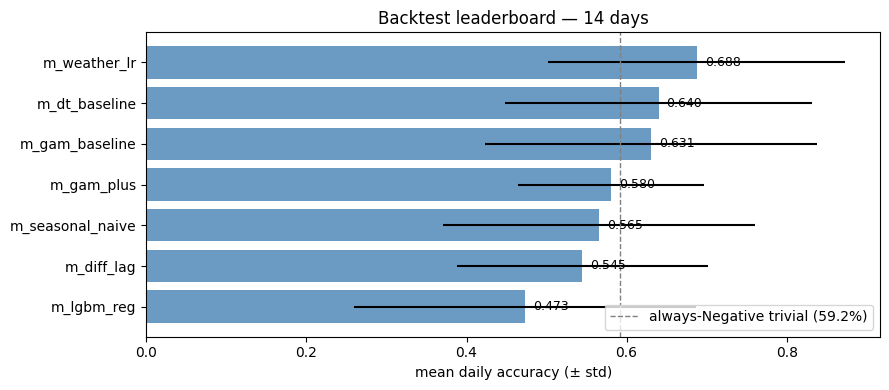

In [3]:
# Bar chart with error bars
fig, ax = plt.subplots(figsize=(9, 4))
y = np.arange(len(latest))
ax.barh(y, latest['mean_acc'], xerr=latest['std_acc'], color='steelblue', alpha=0.8)
ax.set_yticks(y)
ax.set_yticklabels(latest['model'])
ax.invert_yaxis()
ax.set_xlabel('mean daily accuracy (± std)')
ax.axvline(0.592, color='gray', linestyle='--', linewidth=1, label='always-Negative trivial (59.2%)')
ax.legend(loc='lower right')
ax.set_title(f'Backtest leaderboard — {latest["n_days"].iloc[0]} days')
for i, (m, a) in enumerate(zip(latest['model'], latest['mean_acc'])):
    ax.text(a + 0.01, i, f'{a:.3f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

## 2. Per-day accuracy timeseries
Which days are hard for everyone vs only some models?

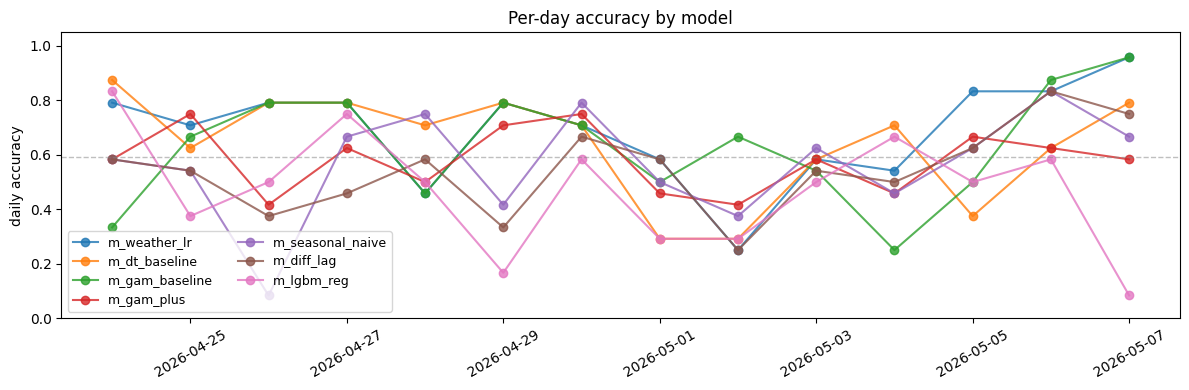

In [4]:
per_day = pd.read_csv('../results/backtest_per_day.csv')
per_day['run_ts'] = pd.to_datetime(per_day['run_ts'])
per_day['date'] = pd.to_datetime(per_day['date'])

# Keep latest run-per-model (matches the leaderboard above)
latest_per_day = (
    per_day.sort_values('run_ts')
           .groupby(['model', 'date'], as_index=False)
           .tail(1)
)

wide = latest_per_day.pivot_table(index='date', columns='model', values='accuracy')
ordered = [m for m in latest['model'].tolist() if m in wide.columns]
wide = wide[ordered]

fig, ax = plt.subplots(figsize=(12, 4))
for col in wide.columns:
    ax.plot(wide.index, wide[col], marker='o', label=col, alpha=0.8)
ax.set_ylabel('daily accuracy')
ax.set_ylim(0, 1.05)
ax.axhline(0.592, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.legend(loc='lower left', ncol=2, fontsize=9)
ax.set_title('Per-day accuracy by model')
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

In [5]:
# Hard days = low *median* accuracy across models. These are the days to study.
median_per_day = wide.median(axis=1).sort_values()
print('Hardest days (median acc across models):')
print(median_per_day.head(5).round(3))
print()
print('Easiest days:')
print(median_per_day.tail(5).round(3))

Hardest days (median acc across models):
date
2026-05-02    0.292
2026-04-26    0.500
2026-04-28    0.500
2026-05-01    0.500
2026-05-04    0.500
dtype: float64

Easiest days:
date
2026-04-29    0.708
2026-04-30    0.708
2026-04-27    0.750
2026-05-07    0.750
2026-05-06    0.833
dtype: float64


## 3. Pairwise correlation
If two models score similarly on the same days, ensembling them won't help.
Models with low correlation are good ensemble candidates.

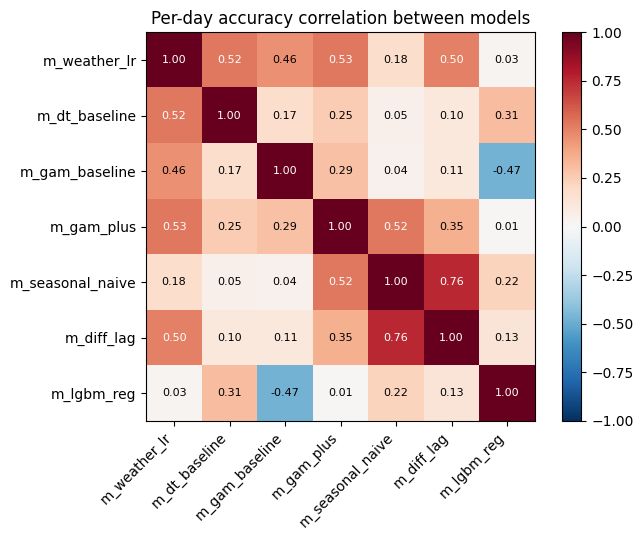

In [6]:
corr = wide.corr()
fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')
plt.colorbar(im, ax=ax)
ax.set_title('Per-day accuracy correlation between models')
plt.tight_layout(); plt.show()

## 4. Confusion analysis — where the winner loses points
Re-run the winning model day-by-day, collect predictions vs truth, build a 3×3
confusion matrix. Tells us *which* class the winner gets wrong (e.g., "misses
Negatives" vs "over-predicts Positive").

In [7]:
import importlib
WINNER = latest.iloc[0]['model']
print(f'Re-scoring winner: {WINNER}')
predict_fn = importlib.import_module(f'models.{WINNER}').predict

# Re-score the same window — use the dates the winner was scored on
winner_dates = sorted(latest_per_day[latest_per_day['model'] == WINNER]['date'].unique())
rows = []
for d in winner_dates:
    d_ts = pd.Timestamp(d).tz_localize('Europe/Istanbul') if pd.Timestamp(d).tzinfo is None else pd.Timestamp(d)
    as_of = d_ts - pd.Timedelta(hours=24)
    start, end = predict_date_window(d_ts)
    grid = load_imbalance_grid(end_dt=end)
    truth_rows = grid[(grid['dt'] >= start) & (grid['dt'] <= end)].sort_values('dt')
    if len(truth_rows) != 24 or truth_rows['system_direction'].isna().any():
        continue
    truth = truth_rows['system_direction'].tolist()
    preds = predict_fn(d_ts, as_of_dt=as_of)
    for h, (p, t) in enumerate(zip(preds, truth)):
        rows.append({'date': d_ts.date(), 'hour': h, 'pred': p, 'truth': t})

calls = pd.DataFrame(rows)
print(f'Total hour-predictions: {len(calls)}')
print('Overall accuracy:', (calls['pred'] == calls['truth']).mean().round(3))

Re-scoring winner: m_weather_lr


Total hour-predictions: 336
Overall accuracy: 0.688


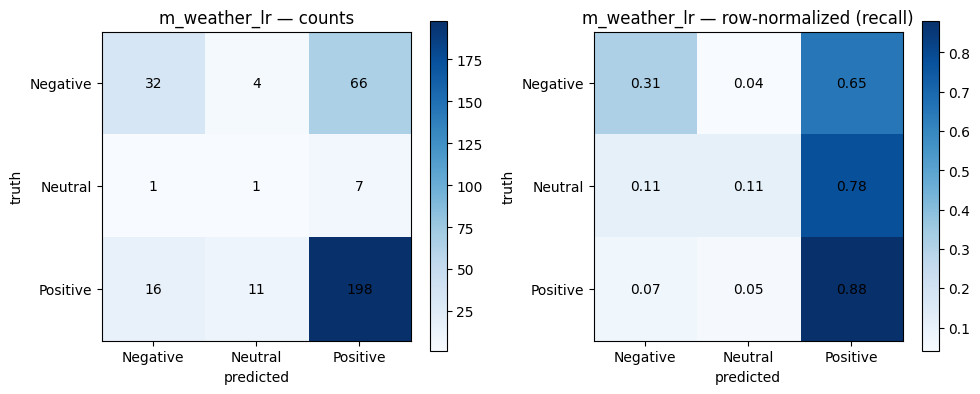

In [8]:
labels = ['Negative', 'Neutral', 'Positive']
cm = pd.crosstab(calls['truth'], calls['pred']).reindex(index=labels, columns=labels, fill_value=0)
cm_norm = cm.div(cm.sum(axis=1), axis=0)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, m, title, fmt in [(axes[0], cm, 'counts', 'd'), (axes[1], cm_norm, 'row-normalized (recall)', '.2f')]:
    im = ax.imshow(m, cmap='Blues')
    ax.set_xticks(range(3)); ax.set_xticklabels(labels)
    ax.set_yticks(range(3)); ax.set_yticklabels(labels)
    ax.set_xlabel('predicted'); ax.set_ylabel('truth')
    ax.set_title(f'{WINNER} — {title}')
    for i in range(3):
        for j in range(3):
            ax.text(j, i, format(m.iloc[i, j], fmt), ha='center', va='center', color='black')
    plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

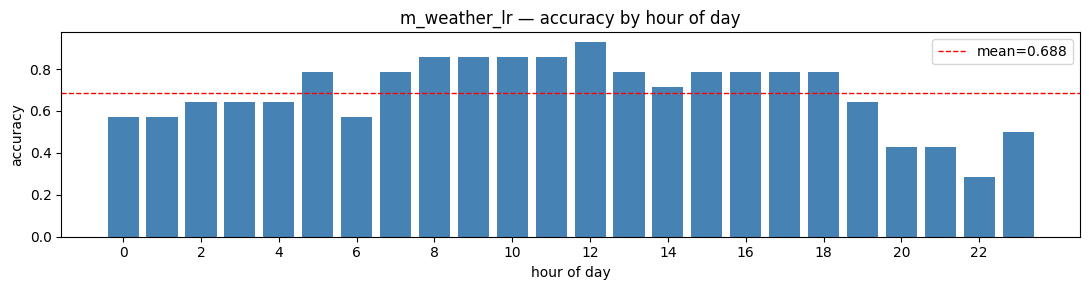

In [9]:
# Per-hour accuracy of the winner — are some hours systematically harder?
hour_acc = calls.groupby('hour').apply(lambda g: (g['pred'] == g['truth']).mean())
fig, ax = plt.subplots(figsize=(11, 3))
ax.bar(hour_acc.index, hour_acc.values, color='steelblue')
ax.axhline(hour_acc.mean(), color='red', linestyle='--', linewidth=1, label=f'mean={hour_acc.mean():.3f}')
ax.set_xlabel('hour of day'); ax.set_ylabel('accuracy')
ax.set_xticks(range(0, 24, 2))
ax.set_title(f'{WINNER} — accuracy by hour of day')
ax.legend()
plt.tight_layout(); plt.show()

## Takeaways for `classify.py`

Fill in after running:

* **Winner:** model with the highest mean accuracy that also beats the always-Negative trivial baseline (59.2%) by a meaningful margin.
* **Bad-day robustness:** if the winner has a much higher std than another model, the other model may be the safer choice for early submissions.
* **Ensemble candidates:** any pair with correlation < 0.5 in section 3 is a good ensemble pair (Phase 5.3).
* **Confusion gaps:** the off-diagonal cells in section 4 tell us which class the winner under-predicts. If we systematically miss Negatives, threshold-shifting at inference time is a cheap fix.
* **Hour-of-day weakness:** hours where accuracy dips below ~50% are candidates for hour-specific models or extra features (e.g., late-evening peaks may need different weather inputs).